# 📊 NDVI & Spectral Indices
**ESIIL STARS 2026 · SICK**

**Prerequisites:** Complete Notebook 1 first.

In this notebook you will:
1. Understand what spectral indices are and why they matter
2. Compute NDVI for CSU campus at two timestamps
3. Map and interpret vegetation change
4. Save publication-quality figures

**⏱ Estimated time:** 30–45 minutes

⚠️ **Branch check** — before running any cells, confirm you are on **your own branch**, not `main`.
In VS Code, open the **Source Control** panel (branch icon in the left sidebar).

1. Look at the current branch name in the Source Control view or status bar."
2. If you are on `main`, click the branch name in the status bar."
3. Choose **Create new branch...** and name it `yourname`."
4. Make sure that new branch is now selected before running notebook cells."

---
## Setup

Run this cell first every session — it imports libraries, authenticates, and rebuilds the AOI and Landsat composites from Notebook 1.

In [10]:
# ── Standard imports ─────────────────────────────────────────────────
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from PIL import Image
from io import BytesIO
from IPython.display import display, HTML

# ── GEE display helper ────────────────────────────────────────────────
def show_map(m):
    """Reliably display a geemap Map in Codespaces."""
    try:
        display(m)
    except Exception:
        display(HTML(m.to_html()))

print("✅ Imports successful!")

✅ Imports successful!


In [11]:
# ⚠️ Replace with YOUR project ID (same one from Notebook 1)
PROJECT_ID = 'ee-xs8091'

ee.Authenticate()
ee.Initialize(project=PROJECT_ID)
print(f"✅ Earth Engine ready — project: {PROJECT_ID}")

✅ Earth Engine ready — project: ee-xs8091


In [12]:
# ── Study area: CSU campus ────────────────────────────────────────────
csu_lon, csu_lat = -105.0844, 40.5734
csu_aoi = ee.Geometry.Point([csu_lon, csu_lat]).buffer(1000).bounds()

# ── Landsat scale-factor helper ───────────────────────────────────────
def apply_scale_factors(image):
    optical = image.select('SR_B.*').multiply(0.0000275).add(-0.2)
    thermal = image.select('ST_B.*').multiply(0.00341802).add(149.0)
    return image.addBands(optical, overwrite=True) \
                .addBands(thermal, overwrite=True)

# ── Thumbnail helper (for saving static figures) ──────────────────────
def get_ee_thumbnail(image, vis_params, region, size=512):
    """Fetch a GEE image as a PIL Image for matplotlib/savefig."""
    params = {**vis_params, 'region': region.getInfo(),
              'dimensions': size, 'format': 'png'}
    url = image.getThumbURL(params)
    return Image.open(BytesIO(requests.get(url).content))

print("✅ Study area and helpers defined!")

✅ Study area and helpers defined!


In [13]:
# Rebuild the Landsat composites from Notebook 1
landsat_2016 = (
    ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
    .filterBounds(csu_aoi)
    .filterDate('2016-06-01', '2016-08-31')
    .filter(ee.Filter.lt('CLOUD_COVER', 10))
    .map(apply_scale_factors)
    .median().clip(csu_aoi)
)
landsat_2024 = (
    ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
    .merge(ee.ImageCollection('LANDSAT/LC09/C02/T1_L2'))
    .filterBounds(csu_aoi)
    .filterDate('2024-06-01', '2024-08-31')
    .filter(ee.Filter.lt('CLOUD_COVER', 10))
    .map(apply_scale_factors)
    .median().clip(csu_aoi)
)
rgb_vis = {'bands': ['SR_B4', 'SR_B3', 'SR_B2'], 'min': 0.0, 'max': 0.3}
print("✅ Landsat composites ready!")

✅ Landsat composites ready!


---
## Part 4: NDVI — Normalized Difference Vegetation Index

### What are spectral indices?

Remote sensing indices are mathematical combinations of spectral bands that highlight specific surface properties. They work because different materials (vegetation, water, soil, snow) have distinctive spectral "fingerprints" — they absorb and reflect light differently at different wavelengths.

### NDVI

$$\text{NDVI} = \frac{\text{NIR} - \text{Red}}{\text{NIR} + \text{Red}}$$

| NDVI value | What it means |
|-----------|---------------|
| < 0 | Water, cloud, snow |
| 0.0 – 0.1 | Bare soil, pavement, rock |
| 0.2 – 0.4 | Sparse or stressed vegetation |
| 0.5 – 0.9 | Dense, healthy vegetation |

**Why it works:** Healthy plants absorb red light for photosynthesis but strongly reflect NIR (their cell structure acts like a mirror for NIR). A high NIR/Red ratio = healthy vegetation. Stressed or dead plants lose this contrast, so NDVI drops.

The normalization (dividing by NIR + Red) removes the effect of illumination differences across the image, making values comparable across scenes and sensors.

In [14]:
def compute_ndvi(image):
    """Add an NDVI band to a Landsat image."""
    ndvi = image.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')
    return image.addBands(ndvi)

ndvi_2016 = compute_ndvi(landsat_2016)
ndvi_2024 = compute_ndvi(landsat_2024)

ndvi_vis = {
    'bands': ['NDVI'],
    'min': -0.1, 'max': 0.8,
    'palette': ['#d73027', '#fc8d59', '#fee08b', '#d9ef8b', '#91cf60', '#1a9850']
}

Map4 = geemap.Map(center=[csu_lat, csu_lon], zoom=14)
Map4.addLayer(ndvi_2016, ndvi_vis, 'NDVI 2016')
Map4.addLayer(ndvi_2024, ndvi_vis, 'NDVI 2024')
Map4.add_colorbar(ndvi_vis, label='NDVI')
show_map(Map4)

Map(center=[40.5734, -105.0844], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

### Save NDVI comparison figure

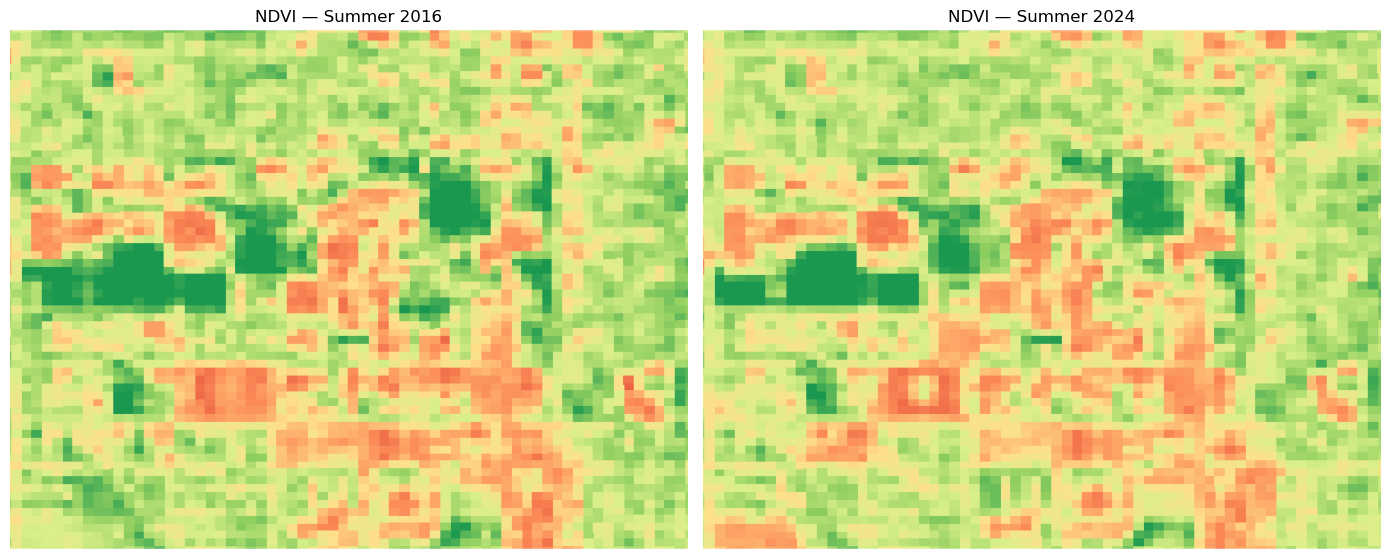

✅ Saved → figures/csu_ndvi_comparison.png


In [15]:
ndvi_thumb_2016 = get_ee_thumbnail(ndvi_2016, ndvi_vis, csu_aoi)
ndvi_thumb_2024 = get_ee_thumbnail(ndvi_2024, ndvi_vis, csu_aoi)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(ndvi_thumb_2016); axes[0].set_title('NDVI — Summer 2016'); axes[0].axis('off')
axes[1].imshow(ndvi_thumb_2024); axes[1].set_title('NDVI — Summer 2024'); axes[1].axis('off')
plt.tight_layout()
plt.savefig('figures/csu_ndvi_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved → figures/csu_ndvi_comparison.png")

### NDVI change detection

Subtracting the 2016 NDVI from 2024 reveals where vegetation has **increased** (positive values) or **decreased** (negative values) over eight years.

In [ ]:
ndvi_change = (ndvi_2024.select('NDVI')
               .subtract(ndvi_2016.select('NDVI'))
               .rename('NDVI_change'))

change_vis = {
    'bands': ['NDVI_change'], 'min': -0.3, 'max': 0.3,
    'palette': ['#d73027', '#f4f4f4', '#1a9850']  # red=loss, white=stable, green=gain
}

Map5 = geemap.Map(center=[csu_lat, csu_lon], zoom=14)
Map5.addLayer(ndvi_change, change_vis, 'NDVI Change 2016→2024')
Map5.add_colorbar(change_vis, label='NDVI change')
show_map(Map5)

# Quick summary stats
stats = ndvi_change.reduceRegion(
    reducer=ee.Reducer.mean().combine(ee.Reducer.minMax(), sharedInputs=True),
    geometry=csu_aoi, scale=30, maxPixels=1e9
).getInfo()
print("NDVI change stats:", stats)

### 🏋️ Exercise 2

**2a.** Save the NDVI change map as `figures/csu_ndvi_change.png`.
Use `get_ee_thumbnail()` with `change_vis` and save with `plt.savefig()`.

**2b.** Look at the change map. Pick **one area that gained** and **one that lost** vegetation. Can you explain why based on what you know about CSU campus?
Write your interpretation as a markdown cell.

**2c. Stretch:** Try computing **NDWI** (Normalized Difference Water Index) — it highlights water bodies. The formula uses Green (B3) and NIR (B5):
```python
ndwi = image.normalizedDifference(['SR_B3', 'SR_B5']).rename('NDWI')
```
Map it and see if you can identify any water features on or near campus.

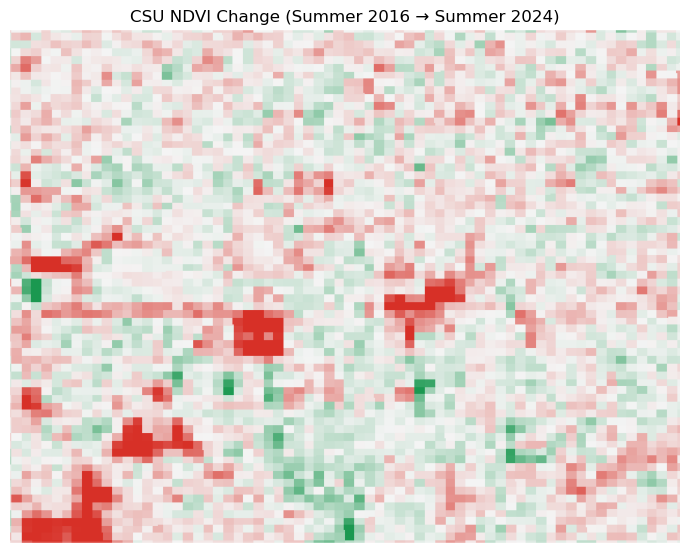

✅ Saved → figures/csu_ndvi_change.png


In [ ]:
# ✏️ Exercise 2a — save NDVI change figure

ndvi_change_thumb = get_ee_thumbnail(ndvi_change, change_vis, csu_aoi)

plt.figure(figsize=(7, 7))
plt.imshow(ndvi_change_thumb)
plt.title('CSU NDVI Change (Summer 2016 → Summer 2024)')
plt.axis('off')
plt.tight_layout()
plt.savefig('figures/csu_ndvi_change.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved → figures/csu_ndvi_change.png")

In [ ]:
# ✏️ Exercise 2c — compute and map NDWI (stretch)

def compute_ndwi(image):
    """Add an NDWI band (Green vs NIR) to a Landsat image."""
    ndwi = image.normalizedDifference(['SR_B3', 'SR_B5']).rename('NDWI')
    return image.addBands(ndwi)

ndwi_2024 = compute_ndwi(landsat_2024)

ndwi_vis = {
    'bands': ['NDWI'],
    'min': -0.5, 'max': 0.5,
    'palette': ['#8c510a', '#f6e8c3', '#c7eae5', '#01665e']
}

Map6 = geemap.Map(center=[csu_lat, csu_lon], zoom=14)
Map6.addLayer(ndwi_2024, ndwi_vis, 'NDWI — Summer 2024')
Map6.add_colorbar(ndwi_vis, label='NDWI')
show_map(Map6)

Map(center=[40.5734, -105.0844], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

---
## 💾 Save Your Work

1. Click the **Source Control** icon (left sidebar) — it looks like a branching tree.
2. Stage all changed files with **+**.
3. Write a commit message, e.g. `"Complete notebook 2 NDVI exercises"`.
4. Click **Commit & Push**.

⚠️ Push to **your branch only**, not `main`.

---
➡️ **Next:** Open **Notebook 3** to explore NLCD land cover and elevation data.